# KNN Life Expectancy Classifier

#Q1. Data Preparation
Load the cleaned csv into a dataframe. Add a new column named HighLifeExpectancy to the dataframe to indicate a country has a high life expectancy. Define this as a country where the Life expectancy variable is greater than 75.0 years.

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/SJGuy-UMN/CSCI4521/refs/heads/main/Life-Expectancy-Data-Updated.csv")
df.head()

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


In [ ]:
#some basic info about data
df.info()
 # 21 columns/features
 # 2864 rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   object 
 1   Region                       2864 non-null   object 
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita    

In [ ]:
df['HighLifeExpectancy'] = (df['Life_expectancy'] > 75.0).astype(int) # 1 classify as >75 and 0 as <75
df.head(5)

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy,HighLifeExpectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5,1
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8,1
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4,0
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0,0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7,1


#Q2. Data Visualization
Choose four numerical features in the dataset (other than Life expectancy itself) that you think may be most indicative of a country’s health. Use the Seaborn pairplot function to make a collection of pairwise scatter plots for these four features. Color the scatter plot points by your new HighLifeExpectancy criteria.
 (Save a screenshot of this figure to include in your report in Part B.)



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

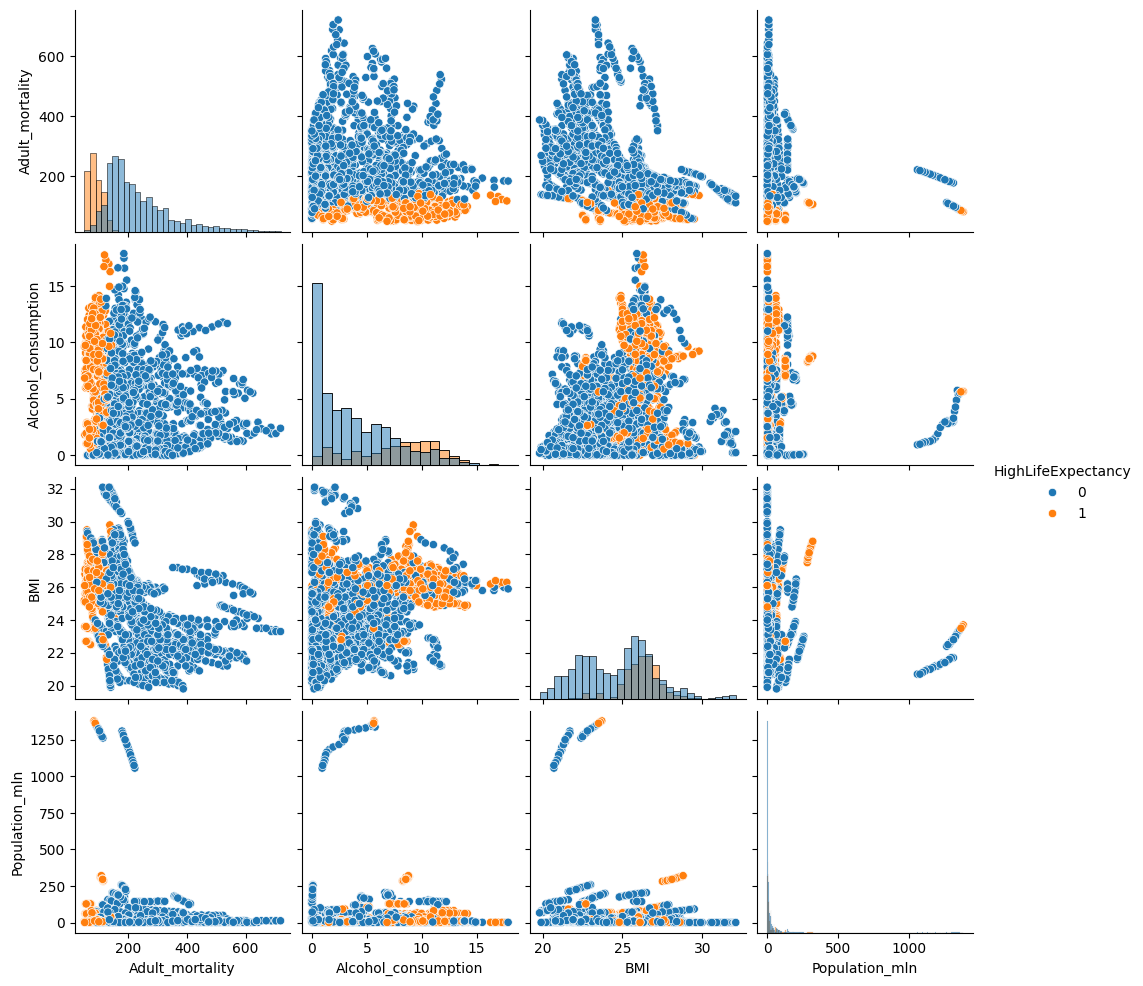

In [ ]:
#  adult_mortatlity, alcohol, Population_mln, BMI

features = ["Adult_mortality",'Alcohol_consumption','BMI','Population_mln']

sns.pairplot(df[features + ["HighLifeExpectancy"]], hue="HighLifeExpectancy", diag_kind="hist")


#Q3. Model building
Create four classifier models that predict if a country has HighLifeExpectancy. Use whatever features you feel makes sense for studying the effects of these health and economic factors (they do not need to be the same features form Q2). The four classifiers you need to implement are:

KNN with a small K of your choice.

KNN with a large K of your choice.

An always-true classifier (predicts "High" for every country).

An always-false classifier (predicts "Low" for every country).

Additional Requirements: For your KNN models you must normalize the input data and split the data into testing and training sets. In the comments of your code, be sure to explain how you avoided data leakage in your normalization.



In [ ]:
#For this i will use 4 same from Q2 ->"Adult_mortality",'Alcohol_consumption','BMI','Population_mln' against HighLifeExpectancy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# features = ["Adult_mortality",'Alcohol_consumption','BMI','Population_mln'] # Defined in Q3

X = df[features]
y = df['HighLifeExpectancy']

# Train/Test 75/25 split, before scaling to avoid data leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state=42,
    stratify = y
)
X_train.shape, X_test.shape,y_train.shape, y_test.shape

# normalized on the training set to avoid data leakage into testing.
scaler = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# small k=2 model
small_knn = KNeighborsClassifier(n_neighbors=2)
small_knn.fit(X_train_scaled, y_train)
y_pred_k2 = small_knn.predict(X_test_scaled)
acc_k2 = accuracy_score(y_test,y_pred_k2)

# large k=500 model
large_knn = KNeighborsClassifier(n_neighbors= 500)
large_knn.fit(X_train_scaled, y_train)
y_pred_k500 = large_knn.predict(X_test_scaled)
acc_k500 = accuracy_score(y_test,y_pred_k500)

# always true model
acc_true = (y_test == 1).mean()
# always false model
acc_false = (y_test == 0).mean()

print("<<<Accuracy % >>>\n")
print(f"K-2:   {acc_k2*100:.3f} %")
print(f"K-500: {acc_k500*100:.3f} %")

print(f"Always True:  {acc_true*100:.2f} %")
print(f"Always False: {acc_false*100:.2f} %")


<<<Accuracy % >>>

K-2:   96.508 %
K-500: 85.196 %
Always True:  27.65 %
Always False: 72.35 %


#Q4. Model Evaluation
For each of the four models above (KNN-small, KNN-large, Always-True, Always-False):

Compute the True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

Write your own code (do not use a library function) to calculate the Precision, Recall, Accuracy, and F1-score using the TP/TN/FP/FN values you found.

Report these metrics for both the Training and Testing datasets.

In [ ]:
import numpy as np

# K-2 model
# checking small knn k-2 model on X_train_scaled and X_test_scaled
y_train_pred_k2 = small_knn.predict(X_train_scaled)
y_test_pred_k2  = y_pred_k2

# K-500 model
# checking large knn k-2 model on X_train_scaled and X_test_scaled
y_train_pred_k500 = large_knn.predict(X_train_scaled)
y_test_pred_k500  = y_pred_k500

# Always True / Always False
y_train_true  = np.ones(len(y_train), dtype=int)
y_test_true   = np.ones(len(y_test), dtype=int)

y_train_false = np.zeros(len(y_train), dtype=int)
y_test_false  = np.zeros(len(y_test), dtype=int)

# Predictions
models = {
    "K-2 model": (y_train_pred_k2, y_test_pred_k2),
    "K-500 model": (y_train_pred_k500, y_test_pred_k500),
    "Always-True": (y_train_true, y_test_true),
    "Always-False": (y_train_false, y_test_false)
}

# Accuracy, Precision, Recall, F1 scores
def compute_metrics(y_actual, y_pred):
    TP = sum((y_actual==1) & (y_pred==1)) # Actually: true,  predicted: true
    TN = sum((y_actual==0) & (y_pred==0)) # Actually: False, predicted: False
    FP = sum((y_actual==0) & (y_pred==1)) # Actually: False, predicted: true
    FN = sum((y_actual==1) & (y_pred==0)) # Actually: true,  predicted: False

    #formulas
    Total =(TP + TN + FP + FN)
    accuracy  = (TP + TN) / Total
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) != 0 else 0
    f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1_score

# Print Test metrics for all models
print(f"{'Models':14} {'Set':4} | {'Acc%':>5} {'Prec%':>10} {'Recall%':>9} {'F1%':>7}")
print("-"*60)

for name, (train_pred, test_pred) in models.items():
    for set_name, y_pred, y_true in [("Train", train_pred, y_train), ("Test", test_pred, y_test)]:
        acc, prec, rec, f1 = compute_metrics(np.array(y_true), np.array(y_pred))

        print(f"{name:13} {set_name:6}| {acc*100:7.3f} {prec*100:9.3f} {rec*100:8.3f} {f1*100:9.3f}")
    print('\n')



# K-2 model    | Acc: 96.508% Prec: 97.268% Recall: 89.899% F1: 93.438%
# K-500 model  | Acc: 85.196% Prec: 75.843% Recall: 68.182% F1: 71.809%
# Always-True  | Acc: 27.654% Prec: 27.654% Recall: 100.000% F1: 43.326%
# Always-False | Acc: 72.346% Prec: 0.000% Recall: 0.000% F1: 0.000%



Models         Set  |  Acc%      Prec%   Recall%     F1%
------------------------------------------------------------
K-2 model     Train |  98.976   100.000   96.296    98.113
K-2 model     Test  |  96.508    97.268   89.899    93.438


K-500 model   Train |  85.801    77.213   69.024    72.889
K-500 model   Test  |  85.196    75.843   68.182    71.809


Always-True   Train |  27.654    27.654  100.000    43.326
Always-True   Test  |  27.654    27.654  100.000    43.326


Always-False  Train |  72.346     0.000    0.000     0.000
Always-False  Test  |  72.346     0.000    0.000     0.000




#Q5. Applying the Model
Consider a hypothetical nation with the statistics listed below:

Adult Mortality: 150 (per 1000 population)
Alcohol: 7.5 (liters per capita)
BMI: 29.0 (average)
Diphtheria: 89 (% coverage)
Hepatitis B: 85 (% coverage)
Incidents of HIV: 0.2 (per 1000 population)
Infant and Child Mortality - both: 27.5 (per 1000 population)
GDP: 16,500 (per capita USD)
Measles: 87 (% coverage)
Polio: 92 (% coverage)
Population: 30 (million)
Schooling: 13.5 (years)
Thinness 5-9 & 10-19 years - both: 2.1 (%)
Use your best performing KNN model to predict if this nation would classify as having "High Life Expectancy."

(Note: If you did not use all of these columns in your model in Q4, simply extract the values for the specific features you did use).

In [ ]:

hypothetical_nation = pd.DataFrame([{
    "Adult_mortality": 150,
    "Alcohol_consumption": 7.5,
    "BMI": 29.0,
    "Population_mln": 30
}])

# scaling
hypothetical_nation_scaled = scaler.transform(hypothetical_nation)

# Predicting based on k-2 model which was best performing
prediction = small_knn.predict(hypothetical_nation_scaled)[0] # get the first index value


if prediction == 1: # 1 means High Life Expectancy
    print(f"Prediction: {prediction}, Hence High Life Expectancy.")
                    # 0 means low Life Expectancy
else:
    print(f"Prediction: {prediction}, Hence Low Life Expectancy.")


Prediction: 0, Hence Low Life Expectancy.
